## Introduction to CID for Categorical Features

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score
import CID_categorical


In [2]:
df = pd.read_csv('Dataset/Mushroom.csv', sep=";")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [3]:
df['class'] = np.where(df['class'] == 'p', 1, 0)

# drop numerical features

columns_to_remove = ['cap-diameter','stem-height','stem-width']
df.drop(columns_to_remove, axis=1, inplace=True)

x = df.drop('class', axis=1)
y = df['class']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

encoder = OrdinalEncoder()
x_train = pd.DataFrame(encoder.fit_transform(x_train),columns=x_train.columns,index=x_train.index)
x_test = pd.DataFrame(encoder.transform(x_test),columns=x_test.columns,index=x_test.index)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9990175208776814


### Random CFs

In [13]:
from Initializer import RANDOM_Categorical

rand = RANDOM_Categorical(model=model,
              training_data=x_train,
              features_names=x_train.columns.tolist())


CID_explainer = CID_categorical.CIDCategoricalExplainer(training_data=x_train,
                                                    features_names=x_train.columns.tolist(),
                                                    target_ft_name='class',
                                                    model=model,
                                                    cf_function=rand,
                                                )



In [85]:
instance = x_train[0:1] 

feature_importances = CID_explainer.explain_instance(instance)

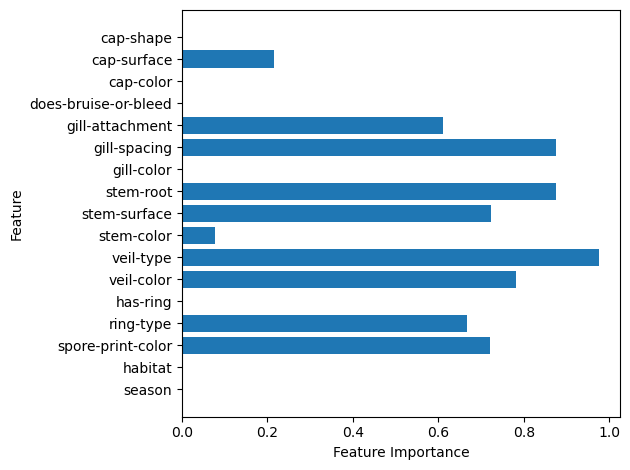

In [86]:
CID_explainer.visualize_feature_importances(feature_importances)

In [14]:
CID_explainer.global_explanation()  

Explaining instances: 100%|██████████| 30/30 [14:43<00:00, 29.46s/it]


,Feature Importance
cap-shape,0.009524
cap-surface,0.477098
cap-color,0.016667
does-bruise-or-bleed,0.000000
gill-attachment,0.637212
gill-spacing,0.865727
gill-color,0.025000
stem-root,0.836469
stem-surface,0.756400
stem-color,0.061966
